## Prediction of speaker dataset

In [59]:
from preprocessing_class import Preprocessing, load_pres
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression,LogisticRegressionCV
from sklearn.svm import LinearSVC,SVC
from nltk.corpus import stopwords
import numpy as np
import string
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:
# load dataset
alltxt, alllabs = load_pres("Dataset/corpus.tache1.learn.utf8")

In [38]:
# M = -1, C = 1
len(alltxt), len(alllabs), np.unique(alllabs)

(57413, 57413, array([-1,  1]))

## Experiment 1
Preprocessing: 
- no stemming or lemming
- lowercase
- remove punctuation
- keep all capital words
- keep names capital
- keep accents
- language French

Vectorization:
- CountVectorizer

Models:
- test on all models possible or what

In [15]:
punc = set(string.punctuation + '\n\r\t')
punc.remove("'") # keep the ' for french words

# Join it back into a string if you need it in that format
custom_punctuation = "".join(punc)

prep = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = None, # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

def preprocess_texts(alltxts):
    return [prep.process(text) for text in alltxts]

cleaned_txts = preprocess_texts(alltxt)

In [16]:
cleaned_txts[0]

" quand je dis chers amis  il ne s'agit pas là d'une formule diplomatique  mais de l'expression de ce que je ressens  "

In [70]:
# vectorization  
#TODO limit to X vocabulary

final_stopwords_list = stopwords.words('french') # stopwords.words('english') 

def build_vectorizer(name="count", stop_words=None, max_features=None,
                     lowercase=False, strip_accents=None, ngram_range=(1,1), use_idf= True, smooth_idf=True, sublinear_tf=False, 
                     max_df=0.95, min_df=0.01, preprocessor = lambda x: x):
    if name == "count":
        vectorizer = CountVectorizer(stop_words=stop_words,max_features=max_features,max_df=max_df,min_df=min_df,ngram_range=ngram_range,lowercase=lowercase,
                                     strip_accents=strip_accents, preprocessor=preprocessor)    
        
    elif name == "tfidf":
        vectorizer = TfidfVectorizer(use_idf= use_idf, smooth_idf=smooth_idf, sublinear_tf=sublinear_tf,max_df=max_df, min_df=min_df, max_features=max_features,
                                     stop_words=stop_words, ngram_range=ngram_range,lowercase=lowercase,strip_accents=strip_accents, preprocessor=preprocessor)
    
    return vectorizer
    ## to implement more embeddings 

def build_embeddings():
    pass

def vectorize_txts(txts,vectorizer):
    X = vectorizer.fit_transform(txts)
    return X

In [71]:
vectoriser = build_vectorizer(name="count", stop_words=final_stopwords_list, max_features=None, preprocessor=prep)
vectorised_all_texts = vectorize_txts(alltxt, vectoriser)

In [72]:
# get the vocabulary and the frequency -> used to check and restreint vocab

import pandas as pd

word_counts = vectorised_all_texts.sum(axis=0).A1  # .A1 flattens it into a 1D array
words = vectoriser.get_feature_names_out()

df_vocab = pd.DataFrame({'word': words, 'count': word_counts})
df_ranked = df_vocab.sort_values(by='count', ascending=False)

print(df_ranked.head(10))

       word  count
118    plus   7443
72   france   5201
25    cette   4883
112    pays   4464
12    aussi   4366
160    être   3808
146    tout   3688
101     nom   3530
145    tous   3457
19     bien   2945


In [73]:
len(df_ranked)

161

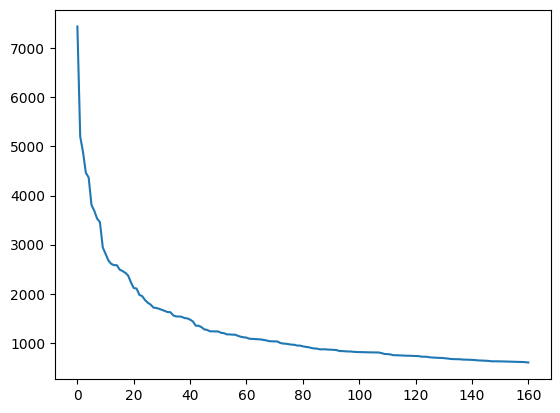

In [74]:
# distribution
plt.plot(df_ranked["count"].values)

In [75]:
X_train, X_test, y_train, y_test  = train_test_split(vectorised_all_texts, alllabs, test_size=0.2, random_state=10, shuffle=True)

In [78]:
## solver = 'newton-cholesky' to try for logistic regression (n_samples >> n_features * n_classes, especially with one-hot encoded categorical features with rare categories)
def build_model(name="kmeans", n_clusters = 8, max_iter = 1000,penalty='l2',loss='squared_hinge',kernel='rbf',solver='lbfgs'):
    if name == "kmeans":
        return KMeans(n_clusters=n_clusters,max_iter=max_iter) 
    elif name == "linear_svm":
        return LinearSVC(penalty=penalty,loss=loss,max_iter=max_iter)
    elif name == "svm":
        return SVC(max_iter=max_iter,kernel=kernel)
    elif name == "logreg":
        return LogisticRegression(solver=solver,max_iter=max_iter)


from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

def pipeline(model,X_train,y_train):
    model.fit(X_train,y_train)
    ypred_train = model.predict(X_train)
    ypred_train_prob = model.predict_proba(X_train)
    ypred = model.predict(X_test)
    ypred_prob = model.predict_proba(X_test)
    print(ypred_prob)
    print(f1_score(y_train,ypred_train),f1_score(y_test,ypred))
    # print(roc_auc_score(y_train, ypred_train_prob), f1_score(y_test,ypred_prob))

    # counts to see the distributions
    print(np.unique(y_train, return_counts=True))
    print(np.unique(ypred_train, return_counts=True))
    print(np.unique(y_test, return_counts=True))
    print(np.unique(ypred, return_counts=True))
    return model

In [79]:
lr = build_model(name="logreg")
lr = pipeline(lr,X_train,y_train)

[[0.17686441 0.82313559]
 [0.27569566 0.72430434]
 [0.09192631 0.90807369]
 ...
 [0.10048637 0.89951363]
 [0.05044615 0.94955385]
 [0.05463556 0.94536444]]
0.9331163240514689 0.9330563686148616
(array([-1,  1]), array([ 6020, 39910]))
(array([-1,  1]), array([ 1051, 44879]))
(array([-1,  1]), array([1503, 9980]))
(array([-1,  1]), array([  281, 11202]))
